## Calculating displacement due to faulting

This notebook will calculate _displacement_ at specified points due to slip on a fault. 

In [80]:
# Import libraries
import pandas as pd
import numpy as np # Numerical analysis
import gmsh # Creation of fault models
import meshio # Interaction between fault model files and Python
import matplotlib.pyplot as plt # Visualize 
from pyproj import Proj
import pyproj
import h5py
%matplotlib widget

In [81]:
# Define some basic coordinate transformation functions
GEOID = pyproj.Geod(ellps="WGS84")
KM2M = 1.0e3
RADIUS_EARTH = np.float64((GEOID.a + GEOID.b) / 2)

def sph2cart(lon, lat, radius):
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)
    x = radius * np.cos(lat_rad) * np.cos(lon_rad)
    y = radius * np.cos(lat_rad) * np.sin(lon_rad)
    z = radius * np.sin(lat_rad)
    return x, y, z

def cart2sph(x, y, z):
    azimuth = np.arctan2(y, x)
    elevation = np.arctan2(z, np.sqrt(x ** 2 + y ** 2))
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    return azimuth, elevation, r

def wrap2360(lon):
    lon[np.where(lon < 0.0)] += 360.0
    return lon

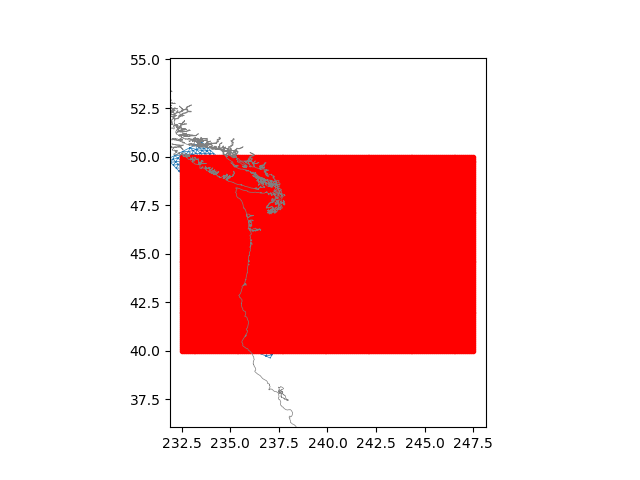

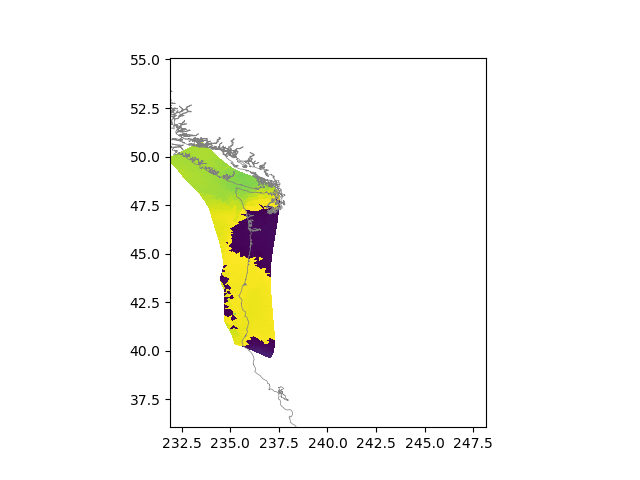

In [82]:
# Read in source fault
# filename = "cascadia.msh"
# filename = "japan.msh"
filename = "cascadia.msh"
mesh = dict()
meshobj = meshio.read(filename)
mesh["file_name"] = filename
mesh["points"] = meshobj.points
mesh["verts"] = meshio.CellBlock("triangle", meshobj.get_cells_type("triangle")).data
ntri = len(mesh["verts"])

# Expand mesh coordinates
mesh["lon1"] = mesh["points"][mesh["verts"][:, 0], 0]
mesh["lon2"] = mesh["points"][mesh["verts"][:, 1], 0]
mesh["lon3"] = mesh["points"][mesh["verts"][:, 2], 0]
mesh["lat1"] = mesh["points"][mesh["verts"][:, 0], 1]
mesh["lat2"] = mesh["points"][mesh["verts"][:, 1], 1]
mesh["lat3"] = mesh["points"][mesh["verts"][:, 2], 1]
mesh["dep1"] = mesh["points"][mesh["verts"][:, 0], 2]
mesh["dep2"] = mesh["points"][mesh["verts"][:, 1], 2]
mesh["dep3"] = mesh["points"][mesh["verts"][:, 2], 2]
mesh["centroids"] = np.mean(mesh["points"][mesh["verts"], :], axis=1)

# Cross products for orientations
tri_leg1 = np.transpose([np.deg2rad(mesh["lon2"] - mesh["lon1"]), np.deg2rad(mesh["lat2"] - mesh["lat1"]), (1 + KM2M * mesh["dep2"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep1"] / RADIUS_EARTH)])
tri_leg2 = np.transpose([np.deg2rad(mesh["lon3"] - mesh["lon1"]), np.deg2rad(mesh["lat3"] - mesh["lat1"]), (1 + KM2M * mesh["dep3"] / RADIUS_EARTH) - (1 + KM2M * mesh["dep1"] / RADIUS_EARTH)])
mesh["nv"] = np.cross(tri_leg1, tri_leg2)
azimuth, elevation, r = cart2sph(mesh["nv"][:, 0], mesh["nv"][:, 1], mesh["nv"][:, 2])
mesh["strike"] = wrap2360(-np.rad2deg(azimuth))
mesh["dip"] = 90 - np.rad2deg(elevation)
mesh["dip_flag"] = mesh["dip"] != 90

# Set up grid where vertical displacement will be calculated

# Cascadia range
# xs = np.linspace(235, 240, 100)
# ys = np.linspace(40, 50, 100)

# Hokkaido range
# xs = np.linspace(143, 146.5, 100)
# ys = np.linspace(41, 43.5, 100)

# any range 
# high_x = np.max(mesh["points"][:, 0])
# low_x = np.min(mesh["points"][:, 0])
# high_y = np.max(mesh["points"][:, 1])
# low_y = np.min(mesh["points"][:, 1])

high_x = 247.5
low_x = 232.5
high_y = 50
low_y = 40

num_points = 100
xs = np.linspace(low_x, high_x, num_points + 50)
ys = np.linspace(low_y, high_y, num_points)

# Reshape grid
obsx, obsy = np.meshgrid(xs, ys)
pts = np.array([obsx, obsy, 0 * obsy]).reshape((3, -1)).T.copy()

# Convert the fault and grid coordinates to Cartesian

# Set up transformation
lon_corr = 1
# Check longitude convention of mesh
if np.max(xs) > 180:
    lon_corr = 0

utmzone=int(32700-(np.sign(np.mean(ys))+1)/2 * 100+np.floor((lon_corr*180 + np.mean(xs))/6) + 1)
target_crs = 'epsg:'+str(utmzone) # Coordinate system of the file
source_crs = 'epsg:4326' # Global lat-lon coordinate system
latlon_to_utm = pyproj.Transformer.from_crs(source_crs, target_crs)

# Convert coordinates
faultxy = np.array(latlon_to_utm.transform(mesh["points"][:, 1], mesh["points"][:, 0])).T/1e3
gridxy = np.array(latlon_to_utm.transform(pts[:, 1], pts[:, 0])).T/1e3 

cart_fault_pts = np.zeros_like(mesh["points"])
cart_fault_pts[:, 0:2] = faultxy
cart_fault_pts[:, 2] = mesh["points"][:, 2]
cart_grid_pts = np.zeros_like(pts)
cart_grid_pts[:, 0:2] = gridxy
cart_grid_pts[:, 2] = pts[:, 2]

# Plot the source fault

# Setting up axis limits 
xmin = np.mean(mesh["points"][:, 0]) - 3*np.std(mesh["points"][:, 0])
xmax = np.mean(mesh["points"][:, 0]) + 3*np.std(mesh["points"][:, 0]) + 8
ymin = np.mean(mesh["points"][:, 1]) - 3*np.std(mesh["points"][:, 1])
ymax = np.mean(mesh["points"][:, 1]) + 3*np.std(mesh["points"][:, 1])

# Read in coastline file
coast = pd.read_csv("coastline.csv")
# Define the figure and its axis
fig, ax = plt.subplots()
# Draw the fault
ax.triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5)
# Add grid points
ax.plot(pts[:, 0], pts[:, 1], '.r')
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()

'''
# Make another plot, showing fault and grid in Cartesian coordinates
fig, ax = plt.subplots()
ax.triplot(cart_fault_pts[:,0], cart_fault_pts[:, 1], mesh["verts"], linewidth=0.5)
ax.plot(cart_grid_pts[:, 0], cart_grid_pts[:, 1], '.r')
ax.set(aspect="equal")
plt.show()
'''

# Show elements colored by strike
fig, ax = plt.subplots()
# Draw the fault
ax.tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=mesh["strike"])
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()


In [83]:
# Calculate the mathematical relationship between unit fault slip and displacement
# This takes a bit of time, but it only needs to be done once if your fault and grid don't change

import cutde.halfspace as cutde

disp_mat = cutde.disp_matrix(obs_pts=cart_grid_pts, tris=cart_fault_pts[mesh["verts"]], nu=0.25)

# Write to HDF5 file
hf = h5py.File("disp_mat.h5", "w")
hf["disp_mat"] = disp_mat
hf.close()

In [84]:
# Read disp_mat from file

hf = h5py.File('disp_mat.h5', 'r')
disp_mat = np.array(hf["disp_mat"])
hf.close()

In [85]:
def radgauss(x0, y0, a, x, y, c):
# 
# RADGAUSS calculates a radial Gaussian distribution.
# 
# S = RADGAUSS(X0, Y0, A, X, Y, C) uses the formula:
# 
# S(Xi, Yi) = A exp(-Ri^2/2C^2)
# 
# to calculate the value S at point (Xi,Yi), which is located a distance
# Ri from point (X0,Y0), where the value is A.  C represents a Gaussian 
# curvature parameter: larger values of C produce more abrupt changes in
# value with distance.
# 
# X0, Y0 represent the x,y coordinates of the point of maximum magnitude A.
# X and Y are n x 1 arrays containing the x,y coordinates of all points at
# which the value S should be calculated.  C is a single value that applies
# to the entire calculation.
# 
# If C is a 2-element vector, the pattern will not be radial but elliptical,
# with the first element of C giving the curvature in the X direction and the
# second giving the curvature in Y:
# 
# S(Xi, Yi) = A exp( [ -(Xi-X0)^2 / 2C[0]^2 ] + [ -(Yi-Y0)^2 / 2C[1]^2] )
# 
# If C is a 3-element vector, an elliptical pattern will result, and the
# ellipse will be rotated C[2] degrees from the y-axis, where a positive 
# number gives a clockwise rotation.
    c = np.array(c)
    if np.size(c) == 1:
        r = np.sqrt((x-x0)**2+(y-y0)**2) # calculate distances
        s = a*np.exp(-r**2/(2*c**2)) # calculate Gaussian value
    elif np.size(c) == 2:
        s = a*np.exp((-(x-x0)**2./(2*c[0]**2)) + (-(y-y0)**2./(2*c[1]**2)))
    elif np.size(c) == 3:
        ang = np.deg2rad(c[2])
        rot = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
        coords = np.vstack((np.hstack((x.T, x0)), np.hstack((y.T, y0))))
        rcoords = rot.dot(coords)
        s = a*np.exp((-(rcoords[0, :-1]-rcoords[0, -1])**2/(2*c[0]**2)) + (-(rcoords[1, :-1]-rcoords[1, -1])**2/(2*c[1]**2)))

    return s  

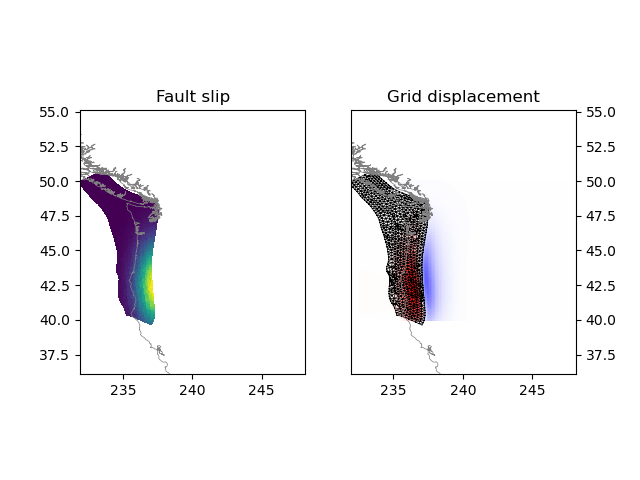

In [86]:
# Uniform fault slip distribution 
# slip = np.zeros_like(mesh["verts"])
# slip[:, 1] = 1 # Uniform dip-slip

# Radial slip distribution 

# Center coordinates of slip distribution
lon_center = 237.5 
lat_center = 42.5
# Stretch of slip gradient in x, y plus rotation angle
slip_shape = np.array([1, 2, 0])
s = radgauss(lon_center, lat_center, 1, mesh["centroids"][:, 0], mesh["centroids"][:, 1], slip_shape)

# Create full slip distribution, adding radial slip as dip-slip 
slip = np.vstack((np.zeros_like(s), s, np.zeros_like(s))).T

# Calculate predicted displacement at grid points that arises from fault slip
pred_disp = disp_mat.reshape((-1, 3*ntri)).dot(slip.reshape(3*ntri, 1))

plt.close('all')
# Visualize the slip and displacement pattern 
fig, ax = plt.subplots(1, 2)
fso = ax[0].tripcolor(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], facecolors=s)
# fig.colorbar(fso, ax=ax[0], orientation='horizontal')
ax[0].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[0].title.set_text("Fault slip")
# Show uplift (pred_disp[2::3])

# Get limits of displacement that is being plotted
plot_disp = pred_disp[2::3]
max_mag = np.max([np.max(plot_disp), np.abs(np.min(plot_disp))])
gdo = ax[1].pcolormesh(obsx, obsy, plot_disp.reshape(np.shape(obsx)), shading="auto", cmap="bwr", vmin=-max_mag, vmax=max_mag)
# Draw the fault
ax[1].triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5, color='k')
# Add coastline
ax[1].plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax[1].set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
ax[1].yaxis.tick_right()
ax[1].title.set_text("Grid displacement")
plt.show()

0.0
-50.0


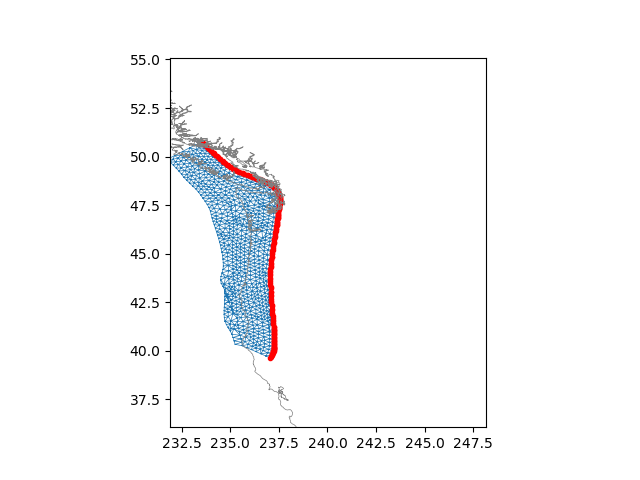

[237.05315, 237.08836, 237.11874, 237.14469, 237.14755, 237.1666, 237.18485, 237.19988, 237.21203, 237.21793, 237.22172, 237.22935, 237.23534, 237.24008, 237.24397, 237.24741, 237.25031, 237.25082, 237.25459, 237.25914, 237.26409, 237.26776, 237.27018, 237.27026, 237.27169, 237.27216, 237.27177, 237.27148, 237.27063, 237.26883, 237.26648, 237.26562, 237.26367, 237.26051, 237.25711, 237.2559, 237.25358, 237.25001, 237.24653, 237.24384, 237.24322, 237.23762, 237.22845, 237.22841, 237.21632, 237.21196, 237.20177, 237.19551, 237.18536, 237.17932, 237.16769, 237.16348, 237.14932, 237.14809, 237.13323, 237.13087, 237.11899, 237.11291, 237.10549, 237.09608, 237.09286, 237.08127, 237.08101, 237.07096, 237.06834, 237.06225, 237.05873, 237.05561, 237.05284, 237.05177, 237.05134, 237.05208, 237.05495, 237.05835, 237.06294, 237.06958, 237.07381, 237.08436, 237.0873, 237.10245, 237.10315, 237.12108, 237.1235, 237.14085, 237.1472, 237.16214, 237.17318, 237.18472, 237.20111, 237.20828, 237.23056, 237

In [87]:
# Find maximum (shallowest) and minimum (deepest) depths of points
# Only check the depths of points listed in verts, using verts as a row index
max_depth = np.max(mesh["points"][mesh["verts"], 2])
print(max_depth)
min_depth = np.min(mesh["points"][mesh["verts"], 2])
print(min_depth)

# Get the indices of the points whose depths are the minuimum 
deepest_points_indices = np.where(mesh["points"][:, 2] == min_depth)[0]
# Get the actual coordinates of these indices
deepest_points = mesh["points"][deepest_points_indices, :]

# Define the figure and its axis
fig, ax = plt.subplots()
# Draw the fault
ax.triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5)
# Add red points along the deepest depth
ax.plot(deepest_points[:, 0], deepest_points[:, 1], '.r')
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()


#finding two distant points
min_lat = np.min(mesh["points"][mesh["verts"], 1])
max_lat = np.max(mesh["points"][mesh["verts"], 1])
east_bound = 245


# finding mins and maxes
lowest_point_index = np.where(mesh["points"][:, 1] == min_lat)[0]
highest_point_index = np.where(mesh["points"][:, 1] == max_lat)[0]
min_lat_x = mesh["points"][lowest_point_index, 0]
max_lat_x = mesh["points"][highest_point_index, 0]

# grouping points for mesh creation
top_x = np.linspace(max_lat_x, east_bound, 15)
bottom_x = np.linspace(min_lat_x, east_bound, 10)
side_y = np.linspace(min_lat, max_lat, 15)

top_y_points = []
bottom_y_points = []
side_x_points = []

for point in top_x:
    top_y_points.append(max_lat)
for point in bottom_x:
    bottom_y_points.append(min_lat)
for point in side_y:
    side_x_points.append(east_bound)

deepest_x = []
for point in deepest_points[:, 0]:
    deepest_x.append(point)

deepest_y_points = []
for point in deepest_points [:, 1]:
    deepest_y_points.append(point)

#flattening and reordering points
top_x_points = []
for list in top_x:
    for item in list:
        top_x_points.append(item)

bottom_x_points = []
for list in bottom_x:
    for item in list:
        bottom_x_points.append(item)

deepest_pairs = {}

for i in range(len(deepest_x)):
    deepest_pairs[deepest_y_points[i]] = deepest_x[i]
deepest_y_points.sort()

deepest_x_points = []
for i in range(len(deepest_x)):
    sorted_i = deepest_pairs.get(deepest_y_points[i])
    deepest_x_points.append(sorted_i)

print(deepest_x_points)

side_y_points = side_y.tolist()
side_y_points.sort()
side_y_points.reverse()
print(side_y_points)

bottom_x_points.sort()
bottom_x_points.reverse()
print(bottom_x_points)


# plotting sides
ax.plot(top_x_points, top_y_points, '-m.')
ax.plot(bottom_x_points, bottom_y_points, '-m.')
ax.plot(side_x_points, side_y_points, '-m.')

# plotting just two points for perimeter
ax.plot(east_bound, max_lat, 'bo')
ax.plot(east_bound, min_lat, 'bo')
print(max_lat)


In [88]:
# z point creation
deepest_z_points = []
for point in deepest_points [:, 2]:
    deepest_z_points.append(point)

bot_depth_change = 0.1
bottom_z = np.linspace(min_depth, min_depth - bot_depth_change, 5)
top_depth_change = bot_depth_change * (east_bound - max_lat_x) / (east_bound - min_lat_x)
top_z = np.linspace(min_depth, min_depth - top_depth_change, 10)
side_z = np.linspace((min_depth - bot_depth_change), (min_depth - top_depth_change), 15)[:,0]

bottom_z_points = []
for point in bottom_z:
    bottom_z_points.append(point)
bottom_z_points.reverse()

side_z_points = []
for point in side_z:
    side_z_points.append(point)
side_z_points.reverse()

top_z_points = []
for list in top_z:
    for item in list:
        top_z_points.append(item)



# removing doubled up points
'''
del top_x_points[9]
del top_y_points[9]
del top_z_points[9]
del side_x_points[14]
del side_y_points[14]
del side_z_points[14]
del bottom_x_points[4]
del bottom_z_points[4]
del bottom_y_points[4]
del deepest_x_points[211]
del deepest_y_points[211]
del deepest_z_points[211]
'''



# creating mesh lists
mesh_x = top_x_points + side_x_points + bottom_x_points + deepest_x_points
mesh_y = top_y_points + side_y_points + bottom_y_points + deepest_y_points 
mesh_z = top_z_points + side_z_points + bottom_z_points + deepest_z_points 

new_mesh_z = []

for i in range(len(mesh_x)):
    new_mesh_z.append(-50.0)

mesh_z = new_mesh_z

if len(mesh_x) == len(mesh_y) and len(mesh_x) == len(new_mesh_z):
    print("check")
else:
    print("fail")
print(len(mesh_x))
print(len(mesh_y))
print(len(mesh_z))

check
252
252
252


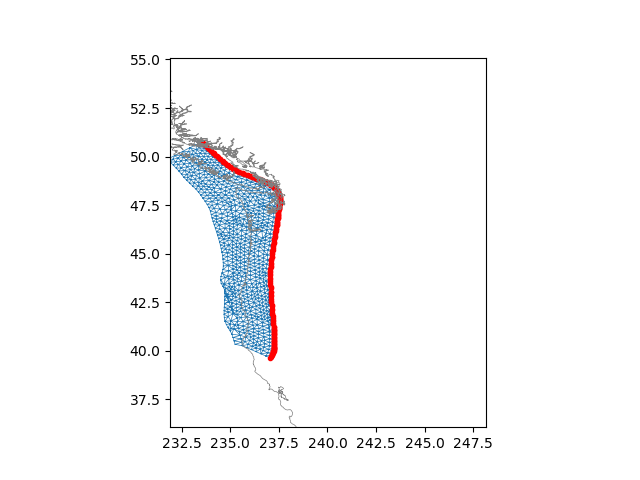

In [89]:
# Define the figure and its axis
fig, ax = plt.subplots()
# Draw the fault
ax.triplot(mesh["points"][:, 0], mesh["points"][:, 1], mesh["verts"], linewidth=0.5)
# Add red points along the deepest depth
ax.plot(deepest_points[:, 0], deepest_points[:, 1], '.r')
# Add coastline
ax.plot(coast.lon+360*(1-lon_corr), coast.lat, color="gray", linewidth=0.5)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
plt.show()
ax.plot(mesh_x, mesh_y, '-m.')

In [90]:
# delete doubled up points

del mesh_x[15]
del mesh_y[15]
del mesh_z[15]
del mesh_x[40]
del mesh_y[40]
del mesh_z[40]


In [91]:

# set up 
if gmsh.isInitialized() == 0:
        gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 0)    
gmsh.clear()


# Making a horizontal mesh

# Get bottom of subduction mesh

# Other perimeter control points

# Define a nominal element size
source_el_size = 5

# Use Gmsh to create the mesh
# Gmsh needs geometric elements defined in order of dimension: 
# Define points
# Define lines that connect those points
# Define perimeter as connections of lines
# Define surface from perimeter
# Mesh the surface into triangles

# Define points
for i in range(len(mesh_x)):
    x = mesh_x[i]
    y = mesh_y[i]
    z = new_mesh_z[i]
    gmsh.model.geo.addPoint(x, y, z, source_el_size, i)

# Define lines, each referencing the index of the 2 points it connects
for j in range(i):
    gmsh.model.geo.addLine(j, j+1, j)
gmsh.model.geo.addLine(j+1, 0, j+1)


lines = []
for i in range(j+2):
    lines.append(i)

# Define curve loop (perimeter), referencing the ordered indices of the lines
gmsh.model.geo.addCurveLoop(lines, 1)





1

In [92]:
# Define surface, referencing the index of the line loop
gmsh.model.geo.addPlaneSurface([1], 0)
gmsh.model.geo.synchronize()
gmsh.write("new_horiz.geo_unrolled")
# Generate and write the mesh. Writing a file allows use of meshio
gmsh.model.mesh.generate(2)
gmsh.write("new_horiz.msh")
gmsh.finalize()



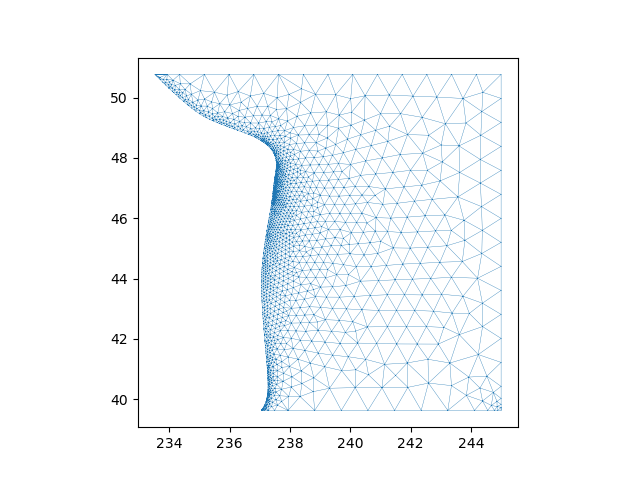

In [93]:
# Read and parse mesh
new_horiz = dict()
new_horizobj = meshio.read("new_horiz.msh")
new_horiz["points"] = new_horizobj.points
new_horiz["verts"] = meshio.CellBlock("triangle", new_horizobj.get_cells_type("triangle")).data
fig, ax = plt.subplots()
# Draw the fault
ax.triplot(new_horiz["points"][:, 0], new_horiz["points"][:, 1], new_horiz["verts"], linewidth=0.25)
ax.set_aspect("equal")
plt.show()